# **Classifier TCGA**
## **Data Loading**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
from scipy.stats import kurtosis, skew

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, adjusted_rand_score, silhouette_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score, classification_report
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from time import time

In [3]:
df = pd.read_csv('tcga_filt.csv')
df = df.drop(columns=['Mutation_Type', 'Protein_Conseq', 'Functional_Conseq', 'Tumor_Type'])

/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_10842/565801488.py:1: DtypeWarning: Columns (18253,18254) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('tcga_filt.csv')


In [4]:
df = df.set_index('Patient_ID')

In [5]:
label = df['Mutated']
X = df.drop(columns='Mutated')

## **Dimensionality Reduction**

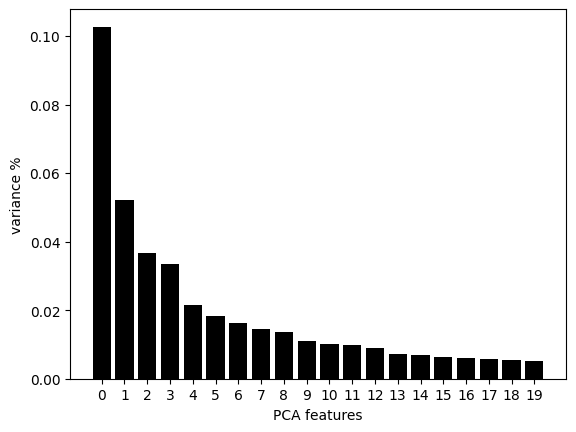

In [13]:
# PCA
df_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
	
pca = PCA(n_components=20)
principalComponents = pca.fit_transform(df_scaled)

features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_, color='black')
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(features)

PCA_components = pd.DataFrame(principalComponents)

explained_variances = pca.explained_variance_ratio_
explained_variances_percentage = explained_variances * 100

cumulative_variances = np.cumsum(explained_variances)
cumulative_variances_percentage = cumulative_variances * 100

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.10270341 0.05221768 0.03674819]


/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_10635/2104994500.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=label, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))


Text(0, 0.5, 'component 2')

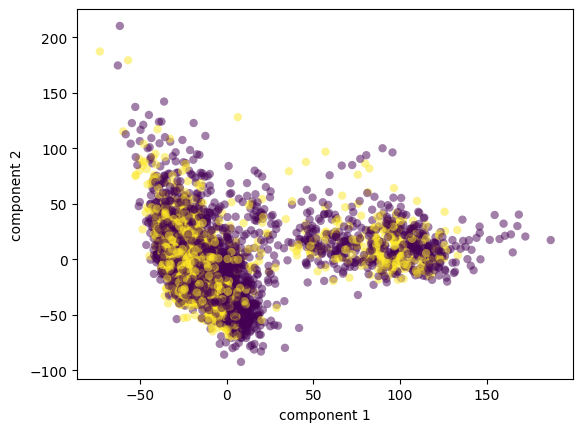

In [15]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=label, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')

/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_10635/330370675.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=label)


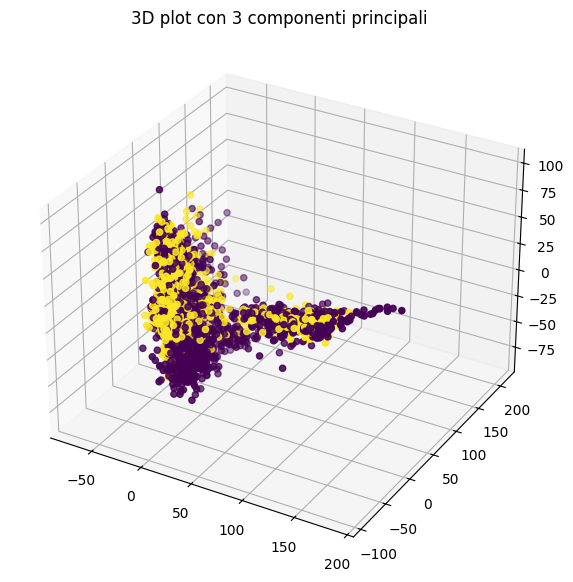

In [16]:
x=X_pca[:, 0]
y=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")

ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=label)
plt.title("3D plot con 3 componenti principali")
plt.show()

## **Clustering**

We try to see whether clustering identifies two different classes correspondig to mutated and not.


Confusion Matrix:
[[2225  440]
 [1345  225]]

Accuracy: 0.5785
Adjusted Rand Index: -0.0071
Silhouette Score: 0.1484

PCA explained variance: [0.10270341 0.05221768]


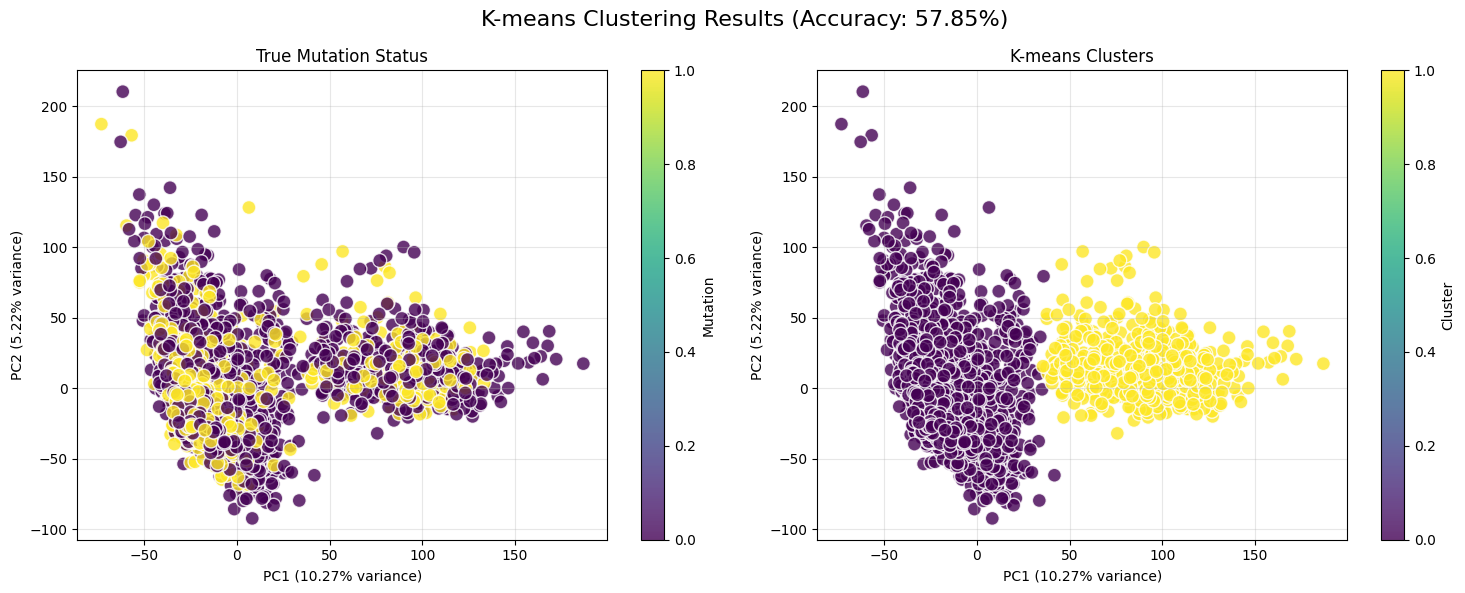

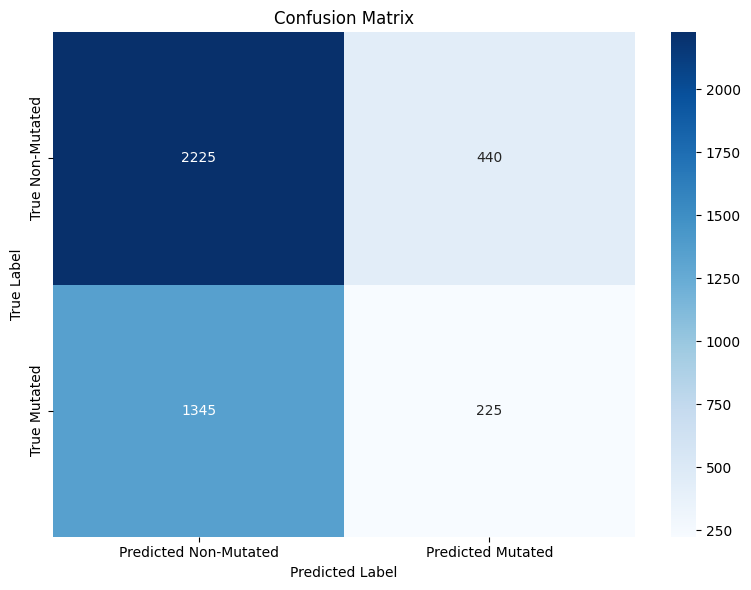

In [6]:
mutation_column = 'Mutation' 

y_true = label

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

accuracy_normal = accuracy_score(y_true, y_pred)
accuracy_flipped = accuracy_score(y_true, 1 - y_pred)

if accuracy_flipped > accuracy_normal:
    print("Cluster labels were flipped to match true labels")
    y_pred = 1 - y_pred
    accuracy = accuracy_flipped
else:
    accuracy = accuracy_normal

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

ari = adjusted_rand_score(y_true, y_pred)
silhouette = silhouette_score(X_scaled, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA explained variance: {pca.explained_variance_ratio_}")

plt.figure(figsize=(15, 6))

# plot 1: True mutation status
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', 
            alpha=0.8, edgecolors='w', s=100)
plt.title('True Mutation Status')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(label='Mutation')
plt.grid(alpha=0.3)

# plot 2: K-means clusters
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='viridis', 
            alpha=0.8, edgecolors='w', s=100)
plt.title('K-means Clusters')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(label='Cluster')
plt.grid(alpha=0.3)

plt.suptitle(f'K-means Clustering Results (Accuracy: {accuracy:.2%})', fontsize=16)
plt.tight_layout()
plt.show()

# confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Non-Mutated', 'Predicted Mutated'],
            yticklabels=['True Non-Mutated', 'True Mutated'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Clustering is really not good at detecting mutation vs wild type.

## **Classifiers** 

Once we have a clear understanding of the data and we have cleaned it as much as possible, we can try and build a predictor of the mutation of TP53.

### **Step 1**
First, we try and classify on the whole dataset. Since we want to see whether the model we have built on CCLE data generalizes to this new dataset as well, we only perform classification using Gradient Boosting with the parameters chosen in the previous notebook.

In [7]:
mutation_column = 'Mutation'  

X = X
y = label

print(f"Class distribution: {np.bincount(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Class distribution: [2665 1570]


In [8]:
model = GradientBoostingClassifier(
                learning_rate=0.1,
                n_estimators=200,
                subsample=0.8,
                random_state=42
            )

model_metrics = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC AUC': [],
    'PR AUC': []
}
model_names = []
confusion_matrices = {}

print(f"\nTraining...")

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")


Training...
Test accuracy: 0.7856


Clearly, accuracy is not too satisfactory. It makes sense that we lose some performance since the data are much more complicated here. Moreover, recall that we have not tried different models nor performed hyperparameter tuning.

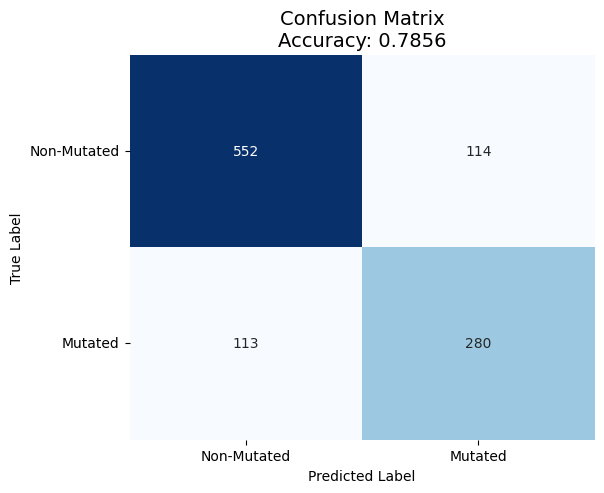

F1 Score: 0.7116
Precision: 0.7107
Recall: 0.7125
ROC AUC: 0.8600


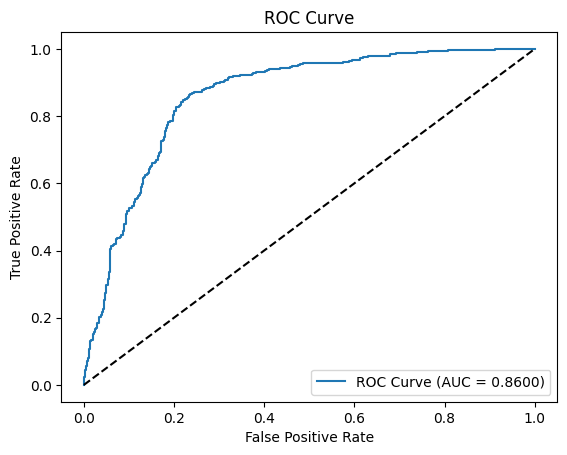


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       666
           1       0.71      0.71      0.71       393

    accuracy                           0.79      1059
   macro avg       0.77      0.77      0.77      1059
weighted avg       0.79      0.79      0.79      1059



In [9]:
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Non-Mutated', 'Mutated'])
plt.yticks([0.5, 1.5], ['Non-Mutated', 'Mutated'], rotation=0)
plt.show()


y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]  # For ROC AUC

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# ROC Curve plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

We have used Gradient Boosting with the parameters we have found on the CCLE data. As a matter of fact, we want to see whether that model generalizes well also to this more complex dataset. Clearly, one could improve the predictions by running further hyperparameter tuning on this data or by comparing different models but that is not our primary goal.

Therefore our final model is: Gradient Boosting with {'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.8}

### **Feature Importance**

In [10]:
feature_importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,  
    'Importance': feature_importances
})

top_10_features = feature_importance_df.sort_values('Importance', ascending=False).head(10)

print("Top 10 Most Important Features:")
for i, (feature, importance) in enumerate(zip(top_10_features['Feature'], top_10_features['Importance']), 1):
    print(f"{i}. {feature}: {importance:.4f}")

Top 10 Most Important Features:
1. SPATA18: 0.0683
2. EDA2R: 0.0670
3. MDM2: 0.0571
4. DDB2: 0.0310
5. PHLDA3: 0.0244
6. STK31: 0.0169
7. RPS27L: 0.0146
8. TP53: 0.0145
9. PCBD2: 0.0128
10. P4HTM: 0.0109


We see that some of the features are the same we found in in CCLE: EDA2R, TP53, MDM2.

### **Step 2**
Now we repeat the analysis but only on a subset of features. In particular, we consider TP53 target genes (i.e. genes directly regulated by TP53).

In [12]:
target_genes = ['CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF', 'FCHO2', 'PANK2', 'TMEM8B', 'RRM2B', 
                'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32', 'SCRIB', 'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 
                'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1', 'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 
                'PRDM1', 'TNFRSF10A', 'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'DF15', 'DRAM1', 'SESN2', 'RAP2B', 
                'TNFRSF10D', 'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6', 'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11',
                'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1', 'POU3F1', 'TSGA10 DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE', 'PHPT1', 'LMNA', 
                'SLC9A1', 'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337', 'DDIT4', 'PIDD1', 'MLF2', 'STAT3', 
                'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2', 'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 
                'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1', 'TM7SF3', 'EDN2', 'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 
                'PTAFR', 'YPEL3', 'RPS27L', 'TRAF4', 'TMEM68', 'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B', 'RALGDS', 'ZNF195', 
                'TNFRSF10B', 'TRIM22', 'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4', 'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A TRIAP1', 
                'CES2', 'ZNF561', 'CERS5', 'PCNA', 'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79', 
                'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7', 'ASCC3', 'DHRS3', 'APAF1', 'SFN', 'PGAP1',
                'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF', 'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C', 'PLCXD2', 'AKAP9', 'COBLL1', 
                'LACC1', 'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1', 'CCDC51', 'CPEB2', 'LPXN', 'SARS', 'PPM1D', 
                'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8', 'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 
                'BLCAP', 'ADCK3', 'PLXNB1', 'DUSP11', 'DNAJB2', 'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3', 'PLXNB2', 
                'GCC2', 'DOCK8', 'MKNK2', 'SDC4', 'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1', 'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 
                'SDPR', 'BLOC1S2', 'DYRK3', 'CPE', 'GRHL3', 'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 
                'CSF1', 'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2', 'DCP1B', 'IGDCC4', 'DGKA', 
                'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1', 'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 
                'EI24', 'MYOF', 'TAB3', 'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA', 'TCAIM', 
                'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2', 'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 
                'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1', 'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 
                'S100A2', 'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15', 'DAPK1', 'SCN2A', 'ARC', 
                'FAM98C', 'P3H2', 'TMEM63B']

In [13]:
df_clean_names = X.rename(columns=lambda x: x.split('[')[0].split('(')[0].strip())

selected_columns = [col for col in df_clean_names.columns if col in target_genes]

df_target = df_clean_names[selected_columns]

In [14]:
df_target.head()

,ABCA12,ABHD4,ABTB2,ACER2,ACTA2,ACYP2,AEN,AIFM2,AK3,AKAP9,...,VCAN,VDR,VWCE,WDR63,YPEL3,ZMAT3,ZNF195,ZNF219,ZNF337,ZNF488
Patient_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J1-01,0.0000,1250.240,94.1402,3.3622,2274.730,755.524,1332.850,816.523,2061.000,959.174,...,167.1470,746.398,237.7520,439.0010,1899.620,197.4060,222.863,1860.230,560.658,2.4015
TCGA-OR-A5J2-01,0.0000,903.905,28.9894,26.5736,2042.930,184.002,205.341,1894.380,2502.750,1992.220,...,4850.8900,927.660,10.4684,181.9890,555.227,178.3650,147.363,686.485,193.971,128.4390
TCGA-OR-A5J3-01,5.3325,3552.070,419.4930,31.4028,1717.420,666.568,1118.650,358.465,521.404,1771.590,...,177.1590,2890.830,107.8360,11.2576,969.338,81.1732,191.379,6022.810,412.099,8.8876
TCGA-OR-A5J5-01,0.7746,3093.730,189.0010,22.4632,659.853,513.555,151.046,2216.110,4247.100,800.929,...,51.1232,441.518,106.1190,11.6189,3713.400,103.0210,328.428,4356.310,841.704,5.4222
TCGA-OR-A5J6-01,0.0000,1655.330,620.3310,16.2068,612.837,1079.150,369.404,1289.280,4564.740,3443.670,...,44.7085,881.876,59.2388,24.5897,2094.040,15.0891,136.361,1079.150,580.445,6.7063


In [15]:
X_target = df_target

X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(
    X_target, y, test_size=0.25, random_state=43, stratify=y
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_targ_scaled = scaler.fit_transform(X_train_target)
X_test_targ_scaled = scaler.transform(X_test_target)

In [16]:
model.fit(X_train_targ_scaled, y_train_target)

y_pred_target = model.predict(X_test_targ_scaled)
test_accuracy = accuracy_score(y_test_target, y_pred_target)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.7819


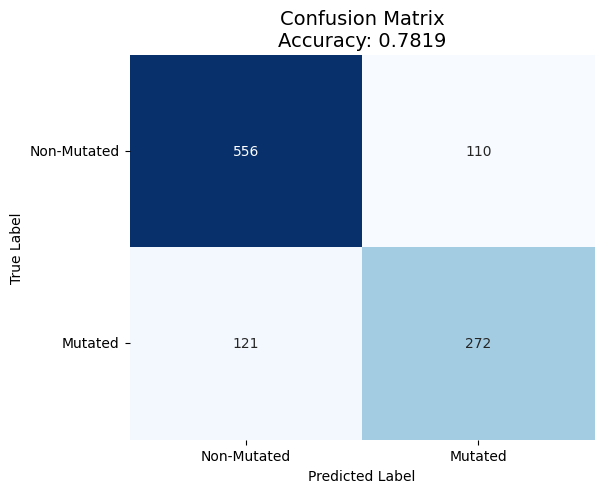

F1 Score: 0.7019
Precision: 0.7120
Recall: 0.6921
ROC AUC: 0.8610


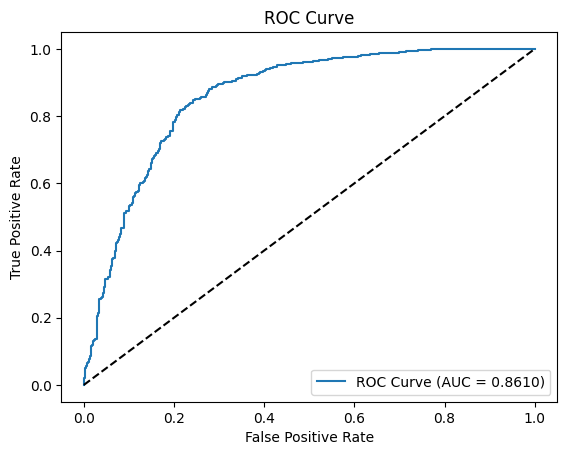


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       666
           1       0.71      0.69      0.70       393

    accuracy                           0.78      1059
   macro avg       0.77      0.76      0.76      1059
weighted avg       0.78      0.78      0.78      1059



In [17]:
cm = confusion_matrix(y_test_target, y_pred_target)
acc = accuracy_score(y_test_target, y_pred_target)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Non-Mutated', 'Mutated'])
plt.yticks([0.5, 1.5], ['Non-Mutated', 'Mutated'], rotation=0)
plt.show()


y_pred_prob = model.predict_proba(X_test_targ_scaled)[:, 1]  # For ROC AUC

f1 = f1_score(y_test_target, y_pred_target)
precision = precision_score(y_test_target, y_pred_target)
recall = recall_score(y_test_target, y_pred_target)
roc_auc = roc_auc_score(y_test_target, y_pred_prob)

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# ROC Curve plot
fpr, tpr, thresholds = roc_curve(y_test_target, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_target, y_pred_target))

Accuracy remains the same! Thus it makes sense to consider only the latter setting, as it is lighter to train and the rest of the genes seem to provide no additional information.